# 3. Model Analysis

This notebook analyzes model predictions and investigates individual creatures.

**Input:**
- `helper_files/engineered_features.parquet`
- `pickled_models/hp_model_cr*.pkl`

**Output:**
- `data/engineered_features.csv`
- `data/feature_contributions.csv`

## Imports and Configs

In [1]:
import numpy as np
import os
import pandas as pd
import sys

from pathlib import Path

In [2]:
# Detect execution context and set paths dynamically
sys.path.insert(0, '.')

# Get the current working directory
cwd = Path.cwd()

# Check if we're in the notebooks directory or project root
if cwd.name == 'notebooks':
    # Running from notebooks directory (in Jupyter)
    DATA_DIR = '../data'
    PICKLED_MODELS_DIR = '../pickled_models'
    MONSTER_BUILDER_DIR = '../monster-builder-v2'
    HELPERS_DIR = './helper_files'
    IO_DIR = './notebooks_io'
    IN_NB_DIR = False
else:
    # Running from project root (via run_three_tier_model.py)
    DATA_DIR = './data'
    PICKLED_MODELS_DIR = './pickled_models'
    MONSTER_BUILDER_DIR = './monster-builder-v2'
    HELPERS_DIR = './notebooks/helper_files'
    IO_DIR = './notebooks/notebooks_io'
    IN_NB_DIR = False

print(f"📁 Execution context detected:")
print(f"   Current directory: {cwd}")
print(f"   Data directory: {DATA_DIR}")
print(f"   Models directory: {PICKLED_MODELS_DIR}")

print("Imports successful")

📁 Execution context detected:
   Current directory: /workspaces/matrix_v0
   Data directory: ./data
   Models directory: ./pickled_models
Imports successful


In [3]:
# Add helper_files to path
if IN_NB_DIR is True:
    from helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS, feature_importance_by_tier
    )

    print("Imports successful")
else:
    from notebooks.helper_files import (
        load_model, get_phase3_features, investigate_creature, summarize_model_performance,
        analyze_predictions_by_cr,
        plot_performance_scatter, plot_error_hist,
        CR_TIERS, feature_importance_by_tier
    )

    print("Imports successful")


Imports successful


## Load Data and Models

In [4]:
import_path = DATA_DIR + '/engineered_features.csv'
df = pd.read_csv(import_path)
df['has_feature_mods'] = df[[c for c in df.columns if 'feature_' in c]].sum(axis=1) > 0

In [5]:
import_path = DATA_DIR + '/feature_contributions.csv'
contributions_df = pd.read_csv(import_path)

In [6]:
phase3_features = get_phase3_features()

In [7]:
results = {}
load_path = PICKLED_MODELS_DIR + "/hp_model_tier.pkl"
# Save each model
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:

    filepath = load_path.replace('tier', tier)
    results[tier] = load_model(filepath)
    print(f"Loaded {tier} model to {filepath}")

print("\nAll models loaded successfully!")

Loaded cr1 model to ./pickled_models/hp_model_cr1.pkl
Loaded cr2 model to ./pickled_models/hp_model_cr2.pkl
Loaded cr3 model to ./pickled_models/hp_model_cr3.pkl
Loaded cr4 model to ./pickled_models/hp_model_cr4.pkl
Loaded cr5 model to ./pickled_models/hp_model_cr5.pkl

All models loaded successfully!


In [8]:
results['cr1'].keys()


dict_keys(['model', 'scaler', 'feature_names', 'train_count', 'test_r2', 'test_mae'])

## Model Analysis

In [9]:
summarize_model_performance(results)


5-BUCKET HP MODEL TRAINING COMPLETE

MODEL PERFORMANCE SUMMARY:

   CR < 1 Model:
      Training samples: 113
      Test R²:  0.3631
      Test MAE: 5.19 HP

   CR 1-4 Model:
      Training samples: 99
      Test R²:  0.2609
      Test MAE: 14.69 HP

   CR 5-10 Model:
      Training samples: 65
      Test R²:  -0.5302
      Test MAE: 28.22 HP

   CR 11-16 Model:
      Training samples: 27
      Test R²:  0.7753
      Test MAE: 12.44 HP

   CR > 16 Model:
      Training samples: 20
      Test R²:  0.3491
      Test MAE: 89.08 HP

All 5 models trained successfully!


In [10]:
# Display top feature coefficients for each tier
for tier in ['cr1', 'cr2', 'cr3', 'cr4', 'cr5']:
    print(f"\n{tier.upper()} Top Features by Coefficient:")
    coefs = results[tier]['model'].coef_
    coef_df = pd.DataFrame({
        'feature': phase3_features,
        'coefficient': coefs
    }).sort_values('coefficient', key=abs, ascending=False)
    coef_df['coefficient'] = coef_df['coefficient'].apply(lambda x: '{:,.0f}'.format(x))
    
    print(coef_df.head(10).to_string(index=False))


CR1 Top Features by Coefficient:
                    feature coefficient
         inflicts_petrified          -1
           inflicts_blinded          -1
         inflicts_paralyzed          -1
     size_ordinal_deviation           1
           has_spellcasting          -0
        inflicts_frightened          -0
        vulnerability_count           0
    has_regeneration_scaled           0
     legendary_action_count           0
legendary_actions_per_round           0

CR2 Top Features by Coefficient:
                    feature coefficient
           inflicts_charmed          -6
         inflicts_petrified          -3
        vulnerability_count           3
         inflicts_paralyzed          -2
     size_ordinal_deviation           1
          inflicts_poisoned          -1
     inflicts_incapacitated          -0
legendary_actions_per_round          -0
     legendary_action_count           0
    has_regeneration_scaled           0

CR3 Top Features by Coefficient:
                  

## Investigate Specific Creatures

In [11]:
[c for c in df.columns if 'hp' in c]

['actual_hp',
 'predicted_hp',
 'hp_delta',
 'hp_delta_pct',
 'hp_delta_pct_percentile',
 'hp_baseline',
 'feature_hp',
 'hp_after_phase2',
 'hp_after_resist_immun_penalty',
 'residual_hp']

In [12]:
df[(df.has_flying==1) & (df.cr_numeric >= 5) & (df.cr_numeric <= 10)].sort_values('predicted_hp')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]

,Name,cr_numeric,actual_hp,predicted_hp,hp_delta_pct
239,Young White Dragon,6.0,133,39.112500,-70.592105
256,Young Bronze Dragon,8.0,142,47.587500,-66.487676
240,Young Brass Dragon,6.0,110,49.237500,-55.238636
241,Mage,6.0,40,54.055947,35.139868
248,Young Black Dragon,7.0,127,55.312500,-56.446850
270,Young Silver Dragon,9.0,168,58.312500,-65.290179
266,Young Blue Dragon,9.0,152,63.937500,-57.935855
252,Young Copper Dragon,7.0,119,74.812500,-37.132353
274,Young Red Dragon,10.0,178,79.312500,-55.442416
257,Young Green Dragon,8.0,136,79.462500,-41.571691


In [13]:
# Interactive investigation
# Uncomment and modify to investigate specific creatures:
# Oni, Unicorn way too penalized for different reasons.
investigate_creature('Oni', df, contributions_df)

  ONI (CR 7.0)

Actual HP:             110
Predicted HP:          107
Error:                  -3  (  -3.1%)

--------------------------------------------------------------------------------

PHASE 1: CR BASELINE
  HP Baseline (CR 7.0):                               156
  Feature HP (DMG adjustments):                       -30
  HP after Phase 1:                                     126

PHASE 2: COMBAT STATS

  Deviation Breakdown:
    Stat         Estimated   Feature    Total  Baseline  Deviation
    ------------------------------------------------------------
    AC                  16        +4       20        15         +5
    Attack               7        +0        7         7         +0
    DPR                 68        +0       68        47        +21
    Save DC             13        --       13        15         -2

  Costed DMG Features:
    feature_ac (+4):  invisibility +1, saving_throws (4 saves) +2, flying (CR 7) +1
    feature_attack (+0):  (none)
    feature_dpr (+0):  (

In [14]:
df[df['Name']=='Cloaker'][[c for c in df.columns if 'dpr' in c]]

,dpr_baseline,estimated_dpr,feature_dpr,legendary_dpr,total_dpr,dpr_deviation
262,53.0,17.5,0.0,0,17.5,-35.5


In [15]:
# _df = analysis_dfs['cr3']
# _df.sort_values('predicted_hp')

In [16]:
# List worst predictions
# print("\nWorst Over-predictions (predicted > actual):")
# over_pred = df[df['hp_delta'] > 0].nlargest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(over_pred.to_string(index=False))

# print("\nWorst Under-predictions (predicted < actual):")
# under_pred = df[df['hp_delta'] < 0].nsmallest(10, 'hp_delta_pct')[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']]
# print(under_pred.to_string(index=False))

# print("\nBest Predictions:")
# df_check_best = df[['Name', 'cr_numeric', 'actual_hp', 'predicted_hp', 'hp_delta_pct']].copy()
# df_check_best['hp_delta_pct_abs'] = df_check_best['hp_delta_pct'].abs()
# best = df_check_best.nsmallest(10, 'hp_delta_pct_abs')
# print(best.to_string(index=False))

# Deatiled Model Breakdown

In [17]:
analysis_dfs = analyze_predictions_by_cr(df)



CR < 1 - Best 10 Predictions:
      Name    CR  Actual_HP  Predicted_HP     Error
Cockatrice 0.500         27     27.000002 -0.000002
   Cultist 0.125          9      9.000003 -0.000003
    Stirge 0.125          2      2.049199 -0.049199
Darkmantle 0.500         22     22.110966 -0.110966
  Commoner 0.000          4      4.125000 -0.125000
       Owl 0.000          1      0.674199  0.325801
 Giant Rat 0.125          7      6.337099  0.662901
Blood Hawk 0.125          7      6.337099  0.662901
  Warhorse 0.500         19     18.287901  0.712099
      Wolf 0.250         11     10.250000  0.750000

CR < 1 - Worst 10 Predictions:
                 Name   CR  Actual_HP  Predicted_HP      Error
                 Drow 0.25         13      2.337394  10.662606
Giant Poisonous Snake 0.25         11      0.000000  11.000000
           Giant Wasp 0.50         13     24.571975 -11.571975
            Hobgoblin 0.50         11     22.625000 -11.625000
                Scout 0.50         16     27.75000

In [18]:
_df_check = analysis_dfs['cr2']
[c for c in _df_check.columns if 'immun' in c]


['hp_after_resist_immun_penalty',
 'immunity_count',
 'feature_spell_immunity',
 'feature_turn_immunity']

In [19]:
# _df_check = analysis_dfs['cr2']
# _df_check[_df_check['actual_hp'] == 45]



📊 VISUALIZATION: Actual vs Predicted HP (5 CR Buckets)


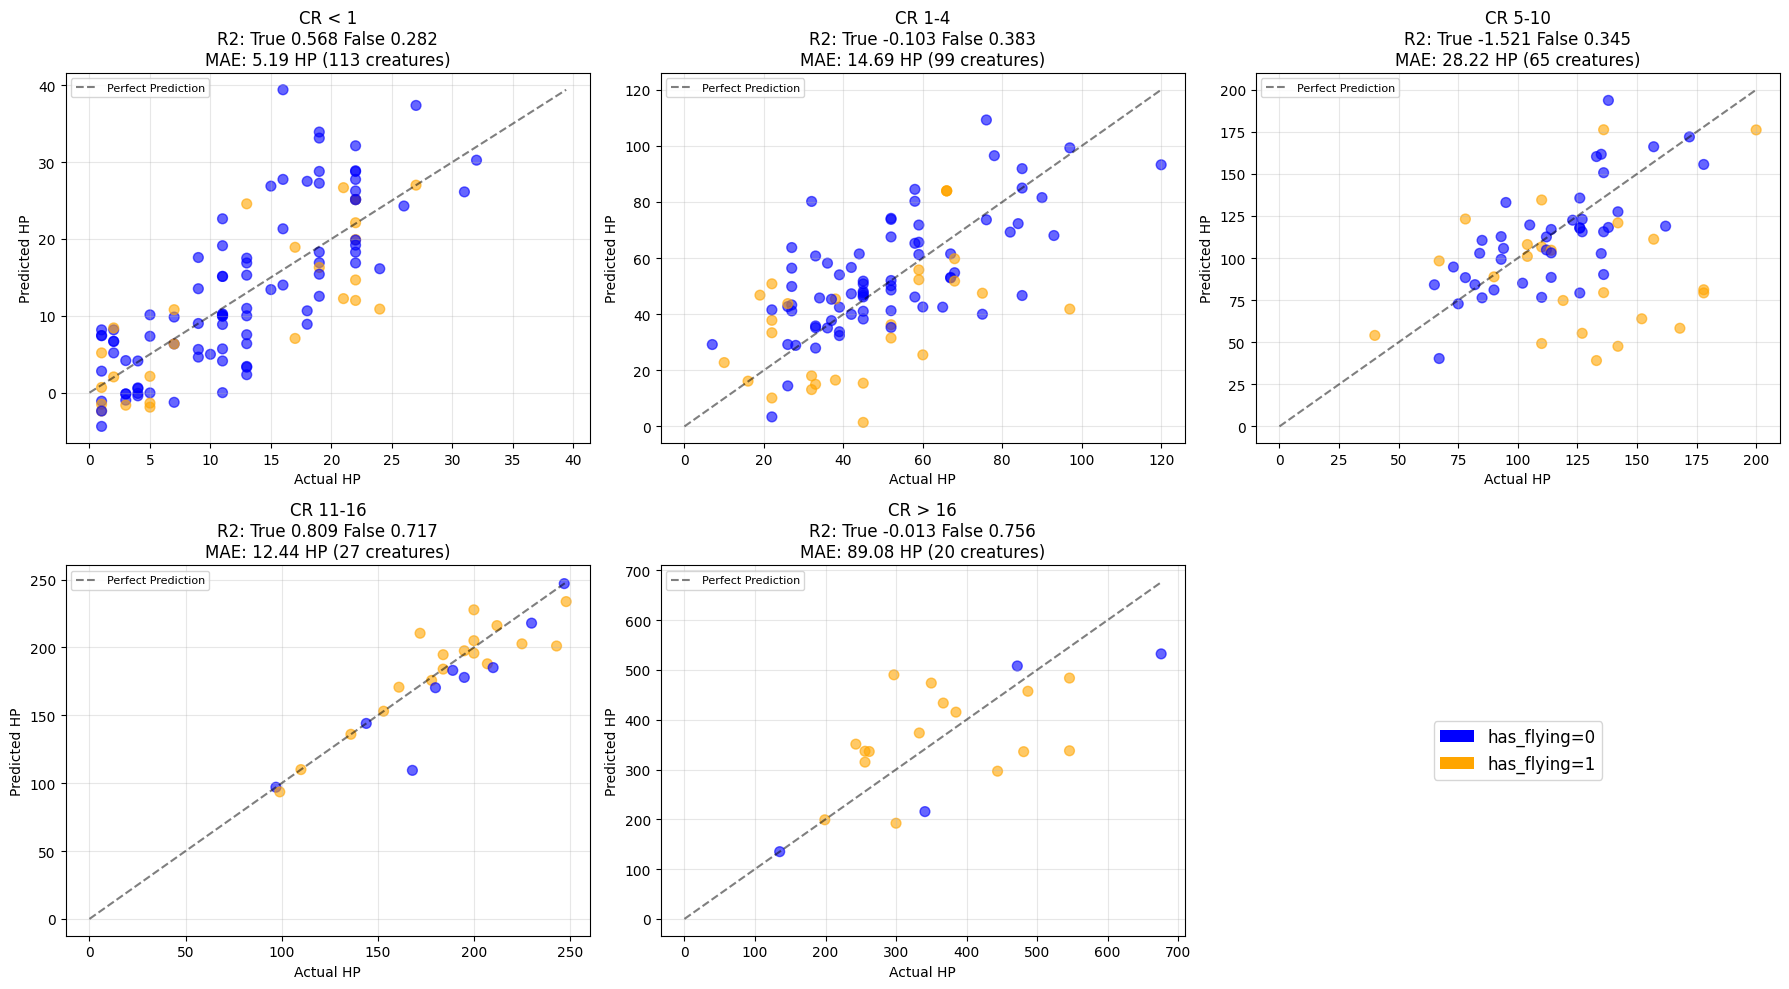

In [26]:

plot_performance_scatter(analysis_dfs, highlight_feature='has_flying')

In [21]:
for k, v in df[df['Name']=='Hill Giant'][[c for c in df.columns if 'feature' in c]].iloc[0].items():
    print(f"{k}: {v}")

feature_dpr: 0.0
feature_ac: 0
feature_attack: 0
feature_hp: 0.0
feature_aggressive: 0
feature_ambusher: 0
feature_amorphous: 0
feature_amphibious: 0
feature_angelic_weapons: 0
feature_antimagic_susceptibility: 0
feature_avoidance: 0
feature_blind_senses: 0
feature_blood_frenzy: 0
feature_breath_weapon: 0
feature_brute: 0
feature_charge: 0
feature_charm: 0
feature_constrict: 0
feature_damage_absorption: 0
feature_damage_transfer: 0
feature_death_burst: 0
feature_devils_sight: 0
feature_dive_attack: 0
feature_echolocation: 0
feature_elemental_body: 0
feature_enlarge: 0
feature_etherealness: 0
feature_false_appearance: 0
feature_fey_ancestry: 0
feature_fiendish_blessing: 0
feature_flyby: 0
feature_frightful_presence: 0
feature_grapple: 0
feature_grappler: 0
feature_hold_breath: 0
feature_horrifying_visage: 0
feature_illumination: 0
feature_immutable_form: 0
feature_incorporeal_movement: 0
feature_innate_spellcasting: 0
feature_invisibility: 0
feature_keen_senses: 0
feature_labyrinthine_r

In [22]:
_df = analysis_dfs['cr3']
_df.sort_values('predicted_hp')

,Name,cr_numeric,actual_hp,predicted_hp,hp_delta,hp_delta_pct,hp_delta_pct_percentile,hp_baseline,ac_baseline,attack_baseline,...,has_attackers_advantage,inflicts_prone,has_grapple,has_feature_mods,Actual_HP,Predicted_HP,CR,Error,Abs_Error,Pct_Error
27,Young White Dragon,6.0,133,39.112500,-93.887500,-70.592105,100.000000,134.4,15.0,7.0,...,0,0,0,True,133,39.112500,6.0,93.887500,93.887500,70.592105
23,Unicorn,5.0,67,40.323656,-26.676344,-39.815439,80.000000,114.0,15.0,7.0,...,0,1,0,True,67,40.323656,5.0,26.676344,26.676344,39.815439
44,Young Bronze Dragon,8.0,142,47.587500,-94.412500,-66.487676,98.461538,163.2,15.0,7.0,...,0,0,0,True,142,47.587500,8.0,94.412500,94.412500,66.487676
28,Young Brass Dragon,6.0,110,49.237500,-60.762500,-55.238636,89.230769,134.4,15.0,7.0,...,0,0,0,True,110,49.237500,6.0,60.762500,60.762500,55.238636
29,Mage,6.0,40,54.055947,14.055947,35.139868,75.384615,134.4,15.0,7.0,...,0,0,0,True,40,54.055947,6.0,-14.055947,14.055947,-35.139868
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39,Giant Ape,7.0,157,166.155688,9.155688,5.831648,18.461538,156.0,15.0,7.0,...,0,0,0,False,157,166.155688,7.0,-9.155688,9.155688,-5.831648
43,Hydra,8.0,172,171.999868,-0.000132,-0.000077,1.538462,163.2,15.0,7.0,...,0,0,0,True,172,171.999868,8.0,0.000132,0.000132,0.000077
57,Cloud Giant,9.0,200,176.155688,-23.844312,-11.922156,38.461538,174.0,16.0,8.0,...,0,0,0,True,200,176.155688,9.0,23.844312,23.844312,11.922156
60,Deva,10.0,136,176.250562,40.250562,29.596002,67.692308,186.0,17.0,9.0,...,0,0,0,True,136,176.250562,10.0,-40.250562,40.250562,-29.596002



📊 VISUALIZATION: Error Distribution (5 CR Buckets)


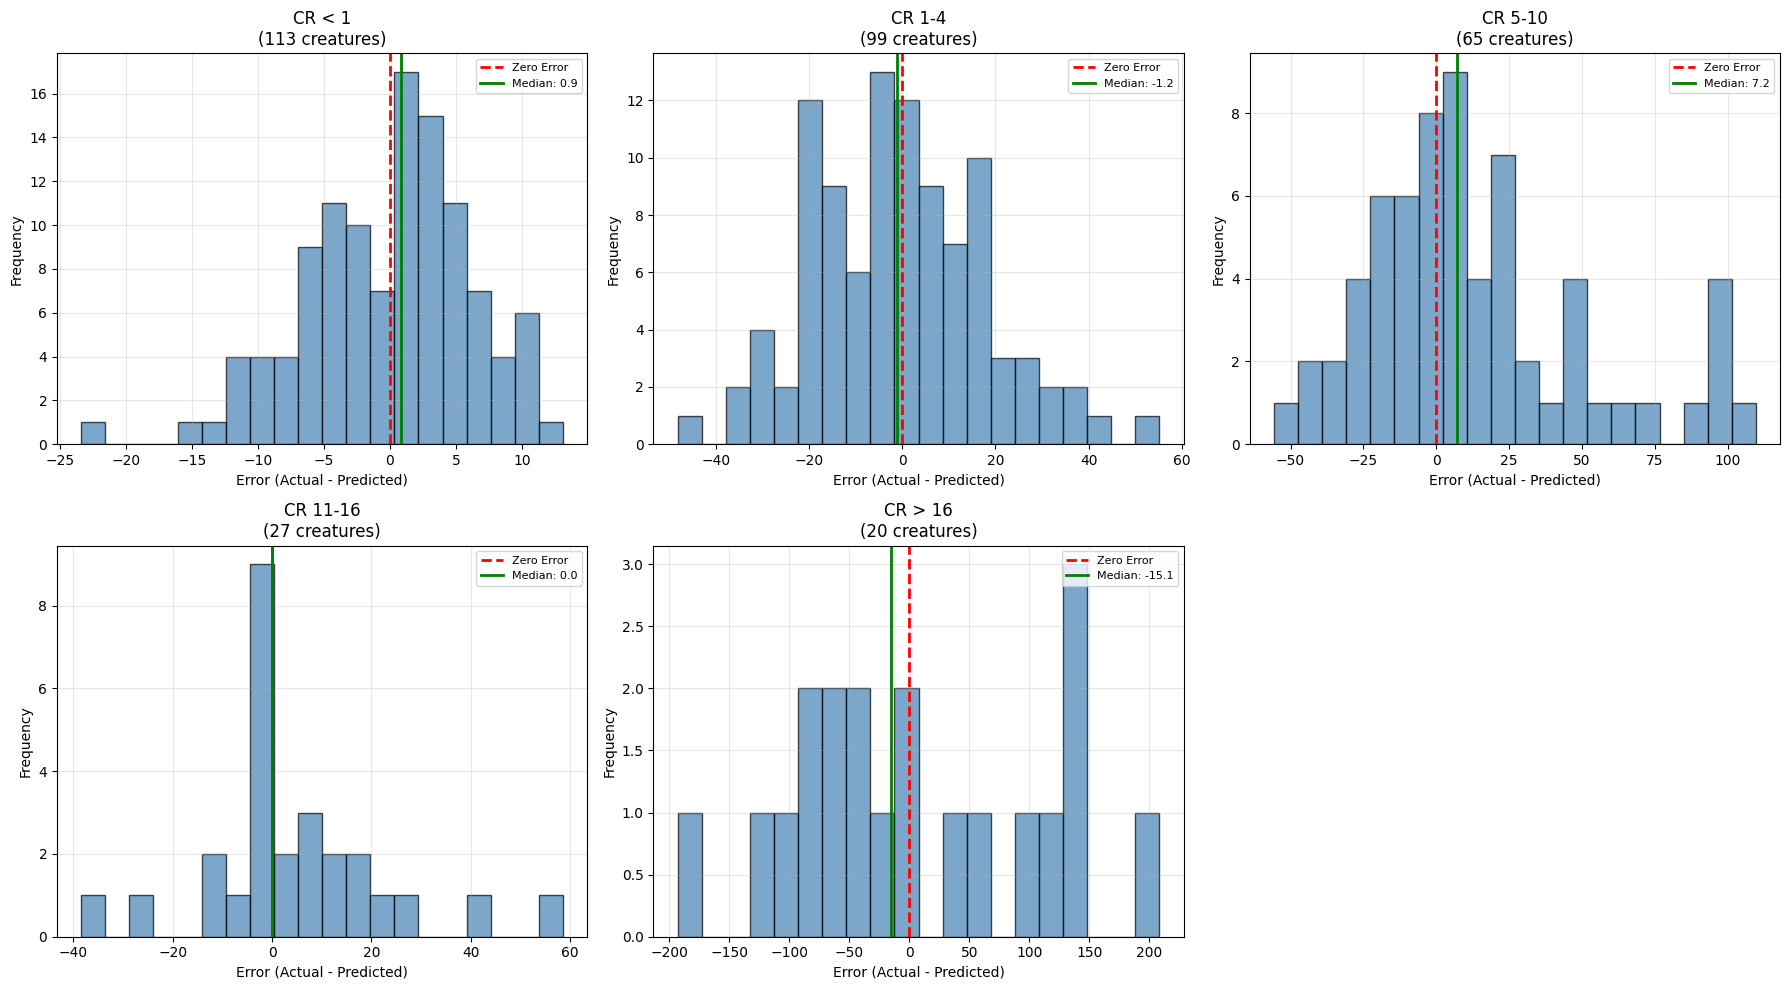

In [23]:
plot_error_hist(analysis_dfs)

# Feature Importance

In [24]:
importance_df = feature_importance_by_tier(contributions_df)

FEATURE IMPORTANCE BY CR TIER

  PHASE 1: AGGREGATE DMG FEATURE COSTS (mean across tier)
  Feature                                 CR < 1     CR 1-4    CR 5-10   CR 11-16    CR > 16
  ------------------------------------------------------------------------------------------
  feature_hp  (HP impact)                   -0.0       -1.2       -3.1      -32.2      -84.0
  feature_dpr  (stat adj.)                   0.4        4.1       10.3       24.9       55.4
  feature_ac  (stat adj.)                    0.2        0.9        1.8        2.6        2.8
  feature_attack  (stat adj.)                0.2        0.1        0.1        0.0        0.0

  PHASE 2: SPECIFIED PENALTIES (mean across tier)
  Feature                                 CR < 1     CR 1-4    CR 5-10   CR 11-16    CR > 16
  ------------------------------------------------------------------------------------------
  ac_deviation                              -1.6       -3.3       -7.2      -10.8      -24.9
    (per unit penalty) 

In [25]:
importance_df

,phase,feature,CR < 1,CR 1-4,CR 5-10,CR 11-16,CR > 16
0,Phase 1,feature_hp,-0.000000,-1.197576,-3.101538,-32.222222,-84.000000
1,Phase 1,feature_dpr,0.429204,4.055556,10.315385,24.851852,55.391667
2,Phase 1,feature_ac,0.212389,0.929293,1.800000,2.555556,2.750000
3,Phase 1,feature_attack,0.212389,0.141414,0.061538,0.000000,0.000000
4,Phase 2,ac_deviation,-1.606195,-3.308081,-7.161538,-10.833333,-24.900000
5,Phase 2,save_dc_deviation,0.061947,0.808081,1.846154,-2.777778,-31.050000
6,Phase 2,attack_deviation,-1.053097,-0.121212,-1.538462,-3.518519,-20.800000
7,Phase 2,dpr_deviation,-1.214602,-0.049832,-1.988782,-0.361111,-11.233333
8,Phase 2,inflicts_prone,-0.079646,-0.170455,-0.207692,-0.833333,-1.950000
9,Phase 2,has_advantage_condition,-0.066372,-0.113636,-0.230769,-0.416667,-0.243750
